In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

/home/lbraun/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


(1920, 1080)

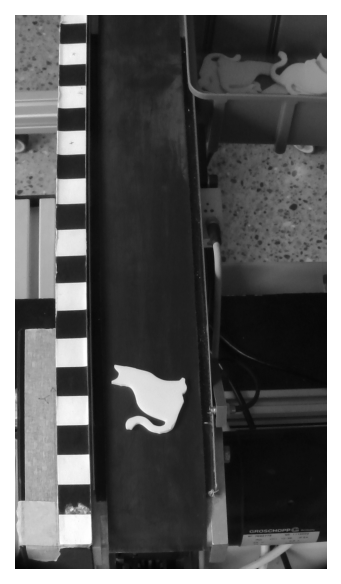

In [2]:
img = cv.imread("foto_10.png")
img = cv.rotate(img, 2)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

fig = plt.imshow(img_gray, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')
img_gray.shape

(640, 195)

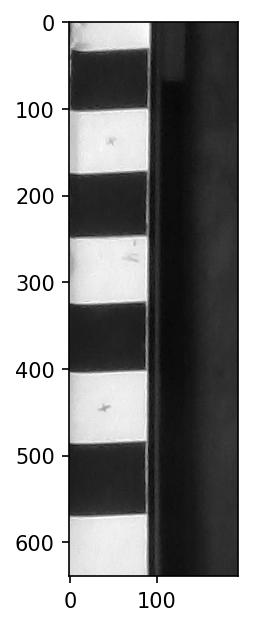

In [3]:
img_gray_focused = img_gray[0:640, 155:350]

fig = plt.imshow(img_gray_focused, cmap = 'gray', vmin=0, vmax=255)
img_gray_focused.shape

/tmp/ipykernel_11109/3416629946.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_gray_focused.ravel(), 256, [0,256])


(array([0.000e+00, 1.000e+00, 4.000e+00, 7.000e+00, 8.000e+00, 6.000e+00,
        1.300e+01, 6.900e+01, 8.000e+01, 2.090e+02, 3.280e+02, 5.010e+02,
        9.820e+02, 1.844e+03, 2.289e+03, 3.187e+03, 1.387e+03, 1.439e+03,
        9.670e+02, 1.789e+03, 2.293e+03, 1.767e+03, 1.461e+03, 2.325e+03,
        9.580e+02, 6.110e+02, 6.820e+02, 8.790e+02, 9.290e+02, 1.040e+03,
        1.287e+03, 2.618e+03, 1.829e+03, 2.221e+03, 3.221e+03, 3.791e+03,
        4.054e+03, 3.623e+03, 2.411e+03, 2.580e+03, 4.258e+03, 2.427e+03,
        2.312e+03, 2.303e+03, 1.945e+03, 1.873e+03, 1.521e+03, 2.519e+03,
        5.022e+03, 2.630e+03, 2.075e+03, 1.471e+03, 9.380e+02, 5.280e+02,
        7.170e+02, 5.990e+02, 8.990e+02, 2.560e+02, 2.100e+02, 1.220e+02,
        9.600e+01, 8.800e+01, 1.020e+02, 1.050e+02, 1.950e+02, 6.800e+01,
        6.300e+01, 4.700e+01, 5.300e+01, 9.300e+01, 4.800e+01, 5.400e+01,
        4.700e+01, 7.900e+01, 4.200e+01, 2.100e+01, 2.900e+01, 5.000e+01,
        4.200e+01, 9.100e+01, 4.700e+0

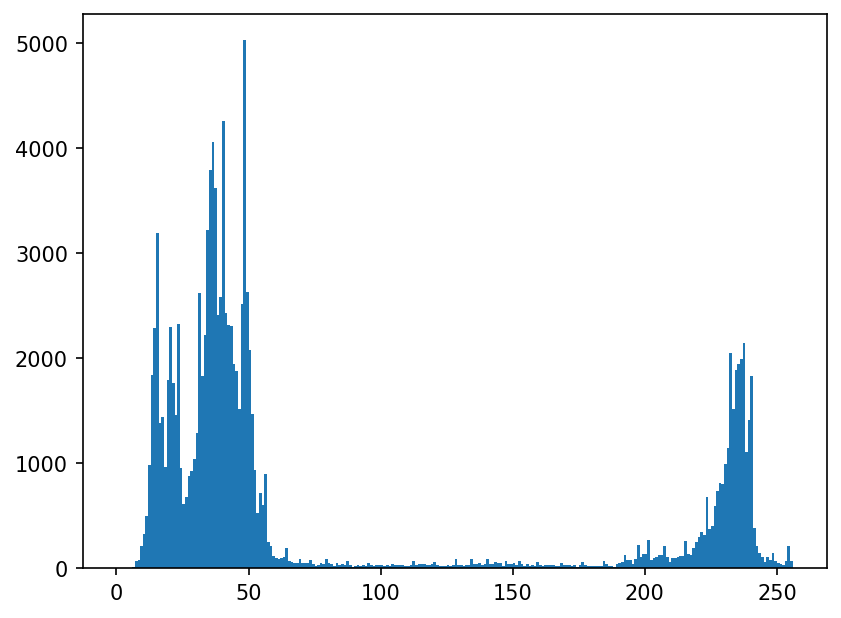

In [4]:
plt.hist(img_gray_focused.ravel(), 256, [0,256])

0.0 255.0


(np.float64(-0.5), np.float64(194.5), np.float64(639.5), np.float64(-0.5))

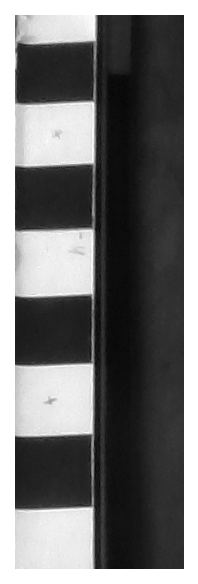

In [5]:
img_spreaded = (img_gray_focused - img_gray_focused.min()) * (255.0 / (img_gray_focused.max() - img_gray_focused.min()))
print(img_spreaded.min(), img_spreaded.max())

fig = plt.imshow(img_spreaded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

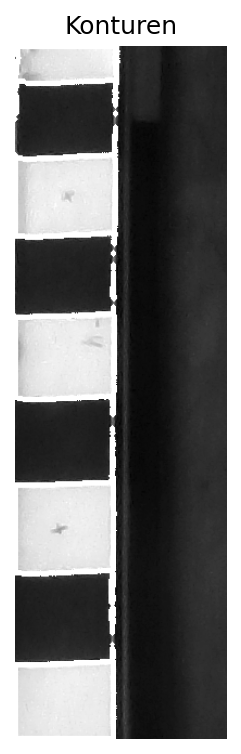

In [6]:
ret , img_thresh = cv.threshold(img_spreaded, 127, 255,cv.THRESH_BINARY)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = img_spreaded.copy()
cv.drawContours(img_with_contours, contours, contourIdx= -1 , color= (255, 255, 255),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')
plt.title('Konturen')
plt.axis('off')
plt.show()